In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime
from typing import Literal, Union
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [2]:
AreaType = Literal["raw", "interim", "processed", "external", "final"]

In [3]:
EXECUCAO_FILE_PATH = '../data/external/Execução Financeira - Política Nacional Aldir Blanc (1).xlsx'
IBGE_TABELA = '../data/external/POP2024_20241230.xls'
ADESAO_FILE_PATH = '../data/external/Adesão - Politica Nacional Aldir Blanc.xlsx'
FINAL_TABLE_FILE_PATH = '../data/final/tabela_final_9_1_2026_19_43.parquet'
GEO_JSON = r'C:\Users\gabiru\Documents\GitHub\projeto_acoes_afirmativas\data\external\br_states.json'


In [4]:
df_execucao = pd.read_excel(EXECUCAO_FILE_PATH)
df_adesao = pd.read_excel(ADESAO_FILE_PATH)
df_tabela = pd.read_parquet(FINAL_TABLE_FILE_PATH)
df_ibge_mun = pd.read_excel(IBGE_TABELA, sheet_name='MUNICÍPIOS')
df_ibge_est = pd.read_excel(IBGE_TABELA)

In [5]:
df_execucao = df_execucao.iloc[1:].reset_index(drop=True)
df_adesao = df_adesao.iloc[1:].reset_index(drop=True)

In [6]:
df_adesao = df_adesao.loc[df_adesao['Ano de Adesão'] == 'Ciclo 1']

In [7]:
df_adesao

,UF do Ente,Nome do Ente,Tipo do Ente,Código IBGE,População,Ano de Adesão,Situação Plano de Ação,Situação Termo de Adesão,Aderiu a política?,Valor do Plano
0,AC,Acrelândia - AC,Município,1200013,14021,Ciclo 1,Autorizado,Assinado,Sim,109558.6
1,AC,Assis Brasil - AC,Município,1200054,8100,Ciclo 1,Autorizado,Assinado,Sim,63890.91
2,AC,Brasiléia - AC,Município,1200104,26000,Ciclo 1,Autorizado,Assinado,Sim,190966.89
3,AC,Bujari - AC,Município,1200138,12917,Ciclo 1,Autorizado,Assinado,Sim,97677.6
4,AC,Capixaba - AC,Município,1200179,10392,Ciclo 1,Autorizado,Assinado,Sim,82780.78
...,...,...,...,...,...,...,...,...,...,...
5420,TO,Tocantinópolis - TO,Município,1721208,22615,Ciclo 1,Autorizado,Assinado,Sim,172927.63
5421,TO,Tupirama - TO,Município,1721257,1909,Ciclo 1,Autorizado,Assinado,Sim,31015.14
5422,TO,Tupiratins - TO,Município,1721307,1874,Ciclo 1,Autorizado,Assinado,Sim,30808.65
5423,TO,Wanderlândia - TO,Município,1722081,10522,Ciclo 1,Autorizado,Assinado,Sim,88413.76


In [8]:
df_execucao = df_execucao.rename(columns={
    'Código IBGE': 'cod_ibge',
    'Total Recebido': 'total_recebido',
    'Rendimentos':'rendimentos'
})

df_adesao=df_adesao.rename(columns={
    'Código IBGE': 'cod_ibge',
    'UF do Ente': 'uf',
    'População': 'populacao',
    'Valor do Plano':'valor_plano'
})

In [9]:
# Execução
df_execucao                   = df_execucao[['cod_ibge', 'total_recebido', 'rendimentos']]
df_execucao['total_recebido'] = df_execucao['total_recebido'].astype(float)
df_execucao['rendimentos']    = df_execucao['rendimentos'].astype(float) 

# Adesão
df_adesao                   = df_adesao[['cod_ibge', 'uf']] 

In [10]:
df_tabela_agg = df_tabela.groupby(['ente_federativo', 'cod_ibge', 'tipo_ente']).agg(
    agg_valor_total=('valor_total', 'sum'),
    agg_valor_cotas_negras=('valor_cotas_negras', 'sum'),
    agg_valor_cotas_indigenas=('valor_cotas_indigenas', 'sum'),
    agg_valor_cotas_pcd=('valor_cotas_pcd', 'sum'),
    agg_vagas_totais   =('vagas_totais', 'sum'),
    agg_vagas_cotas_negras=('vagas_cotas_negras', 'sum'),
    agg_vagas_cotas_indigenas=('vagas_cotas_indigenas', 'sum'),
    agg_vagas_cotas_pcd=('vagas_cotas_pcd', 'sum')
).reset_index()

In [11]:
df_tabela_agg["agg_valor_cotas_total"] = (
    df_tabela_agg["agg_valor_cotas_negras"].fillna(0)
    + df_tabela_agg["agg_valor_cotas_indigenas"].fillna(0)
    + df_tabela_agg["agg_valor_cotas_pcd"].fillna(0)
)

df_tabela_agg["agg_vagas_cotas_total"] = (
    df_tabela_agg["agg_vagas_cotas_negras"].fillna(0)
    + df_tabela_agg["agg_vagas_cotas_indigenas"].fillna(0)
    + df_tabela_agg["agg_vagas_cotas_pcd"].fillna(0)
)

In [12]:
df_tabela_agg = df_tabela_agg.merge(right=df_adesao, how='left', on='cod_ibge')

In [ ]:
df = df_tabela_agg.copy()

df.loc[df['ente_federativo'] == 'RIO DE JANEIRO (capital)', 'uf'] = 'RJ'

# --- Percentuais em VALOR (base: valor_plano) ---
valor_cols = {
    "rel_valor_cotas_negras": "agg_valor_cotas_negras",
    "rel_valor_cotas_indigenas": "agg_valor_cotas_indigenas",
    "rel_valor_cotas_pcd": "agg_valor_cotas_pcd",
    "rel_valor_cotas_total": "agg_valor_cotas_total"
}

for new_col, num_col in valor_cols.items():
    df[new_col] = np.where(
        df["agg_valor_total"].notna() & (df["agg_valor_total"] != 0),
        df[num_col] / df["agg_valor_total"],
        np.nan
    )


# --- Percentuais em VAGAS (base: agg_vagas_totais) ---
vagas_cols = {
    "rel_vagas_cotas_negras": "agg_vagas_cotas_negras",
    "rel_vagas_cotas_indigenas": "agg_vagas_cotas_indigenas",
    "rel_vagas_cotas_pcd": "agg_vagas_cotas_pcd",
    "rel_vagas_cotas_totais": "agg_vagas_cotas_total"
}

for new_col, num_col in vagas_cols.items():
    df[new_col] = np.where(
        df["agg_vagas_totais"].notna() & (df["agg_vagas_totais"] != 0),
        df[num_col] / df["agg_vagas_totais"],
        np.nan
    )


In [123]:
# Valor Pessoas Negras
import matplotlib.colors as mcolors
import pandas as pd
from matplotlib.colors import ListedColormap, BoundaryNorm
cmap_red_custom = mcolors.LinearSegmentedColormap.from_list(
    "red_custom",
    ["#E69E9E", "#CD3C3C", "#922626"]  # claro → escuro
)


# limites (em proporção)
bins = [
    0.0,
    0.20,   # ≤ 20%
    0.24,   # >20% e <24%
    0.25,   # ≥24% e <25%
    0.30,   # ≥25% e ≤30%
    1.0000001  # >30%
]

# cores por faixa, na mesma ordem dos bins
colors = ["#E28D8D", "#D96D6D", "#D14D4D", "#922626", "#511515"]

cmap_cat = ListedColormap(colors)
norm_cat = BoundaryNorm(bins, ncolors=cmap_cat.N, clip=True)

labels = [
    "≤ 20%",
    "> 20% e < 24%",
    "≥ 24% e < 25%",
    "≥ 25% e ≤ 30%",
    "> 30%",
]

In [127]:
# Valor Pessoas Indígenas

bins = [
    0.0,
    0.10 - 1e-6,   # < 10%
    0.10 + 1e-6,   # = 10%
    0.20,          # >10% e ≤20%
    1.0000001      # >20%
]


# cores por faixa, na mesma ordem dos bins
colors = ["#99FF99", "#00B800", "#006600", "#003D00"]

cmap_cat = ListedColormap(colors)
norm_cat = BoundaryNorm(bins, ncolors=cmap_cat.N, clip=True)

labels = [
    "< 10%",
    "= 10%",
    "> 10% e ≤ 20%",
    "> 20%"
]

In [130]:
# Valor PCD

bins = [
    0.0,
    0.05 - 1e-6,   # < 5%
    0.05 + 1e-6,   # = 5%
    0.10,          # > 5% e < 10%
    1.0000001      # ≥ 10%
]
# cores por faixa, na mesma ordem dos bins
colors = ["#D6D6FF", "#0000E0", "#00007A", "#00003D"]

cmap_cat = ListedColormap(colors)
norm_cat = BoundaryNorm(bins, ncolors=cmap_cat.N, clip=True)

labels = [
    "< 5%",
    "= 5%",
    "> 5% e < 10%",
    "≥ 10%",
]

In [105]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
def plot_mapa_estados_continuo(
    df,
    geo_path,
    value_col="rel_valor_cotas_negras",
    modo="ESTADO",
    col_uf_geo="id",      # GeoJSON (UF em 'id')
    col_uf_df="uf",       # seu DF (UF em 'uf')
    bins=None,            # defina fora (escala 0–1)
    labels=None,          # defina fora
    cmap=None,            # ex: ListedColormap([...]) definido fora
    norm=None,            # ex: BoundaryNorm(bins, ncolors=cmap.N, clip=True) definido fora
    right=False,          # importante: 0.10 cai em "≥ 10%" quando right=False
    title=None,
    save_path=None,
    figsize=(10, 10),
    edgecolor="black",
    linewidth=0.7,
    missing_color="#eeeeee",
):
    """
    Plota mapa por UF usando classes (bins/labels) definidas fora.

    Ajuste principal: arredonda TODO valor para o percentual inteiro mais próximo (half-up)
    e volta para proporção (0–1), criando a coluna auxiliar: f"{value_col}_p1".

    Ex:
      0.097 -> 0.10 (9.7% -> 10%)
      0.094 -> 0.09 (9.4% -> 9%)
      0.015 -> 0.02 (1.5% -> 2%)
    """
    if bins is None or labels is None or cmap is None or norm is None:
        raise ValueError("Passe bins, labels, cmap e norm (definidos fora da função).")

    # --- GEO ---
    g = gpd.read_file(geo_path).copy()
    g["uf"] = g[col_uf_geo].astype(str).str.strip().str.upper()

    # --- BASE ---
    d = df.copy()
    d[col_uf_df] = d[col_uf_df].astype(str).str.strip().str.upper()

    if modo.upper() == "ESTADO":
        d = d[d["tipo_ente"].astype(str).str.upper().eq("ESTADO")].copy()
    elif modo.upper() == "CAPITAL":
        d = d[d["tipo_ente"].astype(str).str.upper().eq("CAPITAL")].copy()
    else:
        raise ValueError("modo deve ser 'ESTADO' ou 'CAPITAL'")

    base = (
        d.groupby(col_uf_df, as_index=False)[value_col]
         .mean()
         .rename(columns={col_uf_df: "uf"})
    )

    # --- MERGE ---
    m = g.merge(base, on="uf", how="left")

    # --- ARREDONDAMENTO (half-up) EM PASSOS DE 1% E VOLTA PRA 0–1 ---
    # cria coluna auxiliar: value_col + "_p1"
    vc_p1 = value_col + "_p1"
    m[vc_p1] = np.floor(m[value_col].astype(float) * 100 + 0.5) / 100

    # --- CLASSE (opcional, útil pra debug/legenda) ---
    m["classe"] = pd.cut(
        m[vc_p1],
        bins=bins,
        labels=labels,
        include_lowest=True,
        right=right
    )

    # --- PLOT ---
    fig, ax = plt.subplots(figsize=figsize)

    m.plot(
        column=vc_p1,          # <-- NOME da coluna (string)
        cmap=cmap,
        norm=norm,
        linewidth=linewidth,
        edgecolor=edgecolor,
        ax=ax,
        missing_kwds={"color": missing_color, "label": "Sem dado"},
    )

    ax.set_axis_off()
    if title is None:
        title = f"Brasil — {value_col} ({modo.capitalize()})"
    ax.set_title(title)

    # --- COLORBAR DISCRETA COM LABELS ---
    sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm._A = []
    cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)

    # ticks no meio de cada bin
    midpoints = [(bins[i] + bins[i+1]) / 2 for i in range(len(bins) - 1)]
    cbar.set_ticks(midpoints)
    cbar.set_ticklabels(labels)
    cbar.set_label(value_col)

    plt.tight_layout()

    if save_path:
        from pathlib import Path
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(f"{save_path}.png", dpi=300, bbox_inches="tight", format="png")
        fig.savefig(f"{save_path}.svg", bbox_inches="tight", format="svg")

    plt.show()
    plt.close(fig)


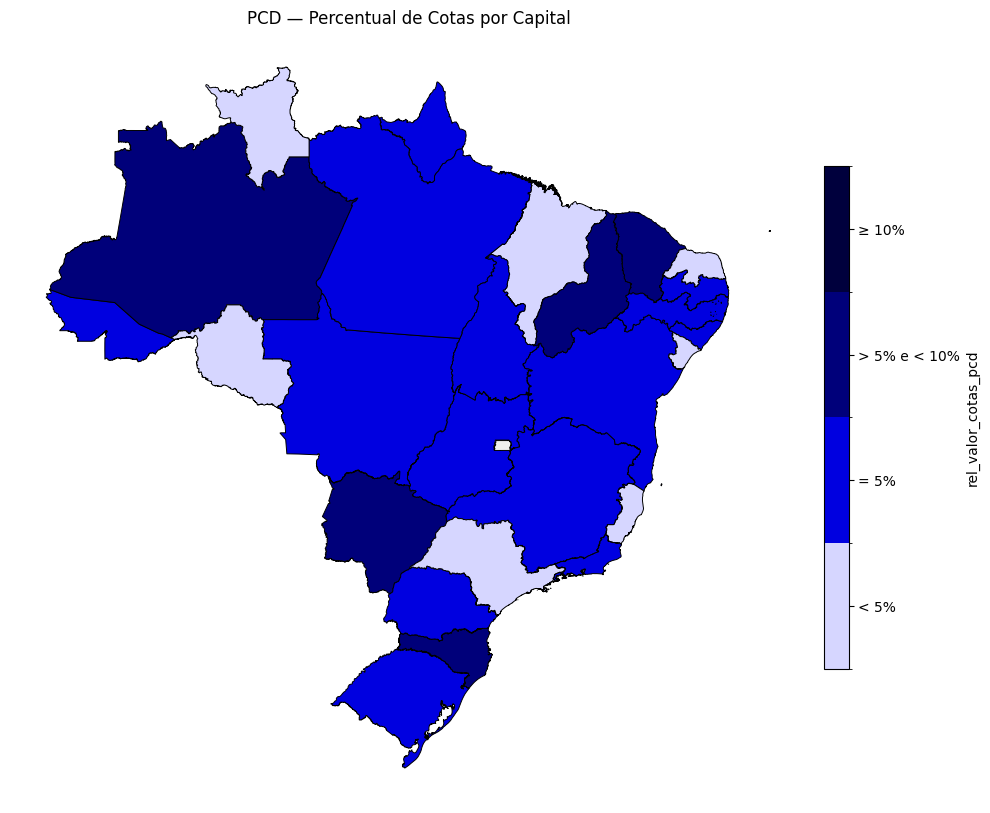

In [134]:
plot_mapa_estados_continuo(
    df=df,
    geo_path=GEO_JSON,
    value_col="rel_valor_cotas_pcd",   # <-- coluna que você quer mapear
    modo="CAPITAL",
    bins=bins,
    labels=labels,
    cmap=cmap_cat,
    norm=norm_cat,
    right=False,                       # garante que 0.10 → "≥ 10%"
    title="PCD — Percentual de Cotas por Capital",
    save_path="outputs/mapa_pcd_capital"
)

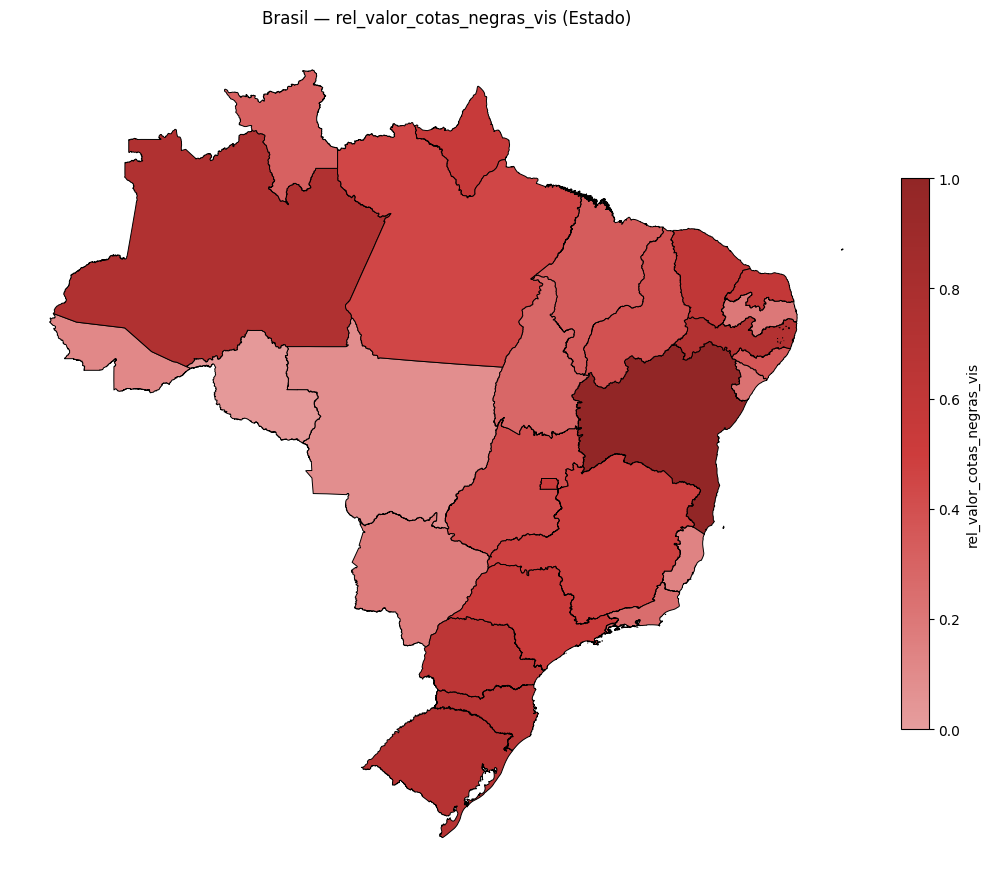

In [34]:
import numpy as np

tmp = df.copy()
mask = tmp["tipo_ente"].str.upper().eq("ESTADO")

x = tmp.loc[mask, "rel_valor_cotas_negras"]
r = x.rank(pct=True)                 # 0..1 bem espalhado
tmp.loc[mask, "rel_valor_cotas_negras_vis"] = 0.7*r + 0.3*((x - x.min())/(x.max()-x.min()))

plot_mapa_estados_continuo(
    tmp, GEO_JSON,
    value_col="rel_valor_cotas_negras_vis",
    modo="ESTADO",
    vmin=0, vmax=1,
    cmap=cmap_red_custom
)

In [49]:
def save_to_excel_safe(
    dataframe: pd.DataFrame,
    file_name: str,
    area: AreaType = "interim",
) -> Path:
    """
    Salva DataFrame em Excel sem o Excel alterar zeros à esquerda, formatos ou datas.
    Força colunas do tipo objeto a serem salvas como texto.
    """
    data_path = Path(r"C:\Users\gabiru\Documents\GitHub\projeto_acoes_afirmativas\data")
    file_path = Path(data_path / area / file_name)

    with pd.ExcelWriter(file_path, engine="xlsxwriter") as writer:
        dataframe.to_excel(writer, index=False, sheet_name="data")
        workbook = writer.book
        worksheet = writer.sheets["data"]

        text_fmt = workbook.add_format({"num_format": "@", "text_wrap": False})

        for idx, dtype in enumerate(dataframe.dtypes):
            if dtype == object:
                worksheet.set_column(idx, idx, None, text_fmt)

    return 


In [51]:
save_to_excel_safe(df, file_name='tabela_agg_12_1_26_9_45.xlsx', area='processed')

In [50]:
df.columns

Index(['ente_federativo', 'cod_ibge', 'tipo_ente', 'agg_valor_total',
       'agg_valor_cotas_negras', 'agg_valor_cotas_indigenas',
       'agg_valor_cotas_pcd', 'agg_vagas_totais', 'agg_vagas_cotas_negras',
       'agg_vagas_cotas_indigenas', 'agg_vagas_cotas_pcd',
       'agg_valor_cotas_total', 'agg_vagas_cotas_total',
       'rel_valor_cotas_negras', 'rel_valor_cotas_indigenas',
       'rel_valor_cotas_pcd', 'rel_valor_cotas_total',
       'rel_vagas_cotas_negras', 'rel_vagas_cotas_indigenas',
       'rel_vagas_cotas_pcd', 'rel_vagas_cotas_totais'],
      dtype='object')